## **Lorenz 96 Model Learned by SREINet**


## **I. Setup and Preprocessing**

In [46]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG


# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("**********************************************")

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') and version.parse(tf.__version__) > version.parse('2.15.0'):
    print("Error: Tensorflow version is lower than 2.10.0 or higher than 2.15.0 Please use Tensorflow 2.10.0 - 2.15.0")
    sys.exit()

MY_DATA_TYPE = 'float32'
# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  


**********************************************
*                                            *
*    Tensorflow Version: 2.15.0              *
*                                            *
**********************************************


### **1.2 Training Data**

#### Create dataset

Guessed highest order polynomial: 2


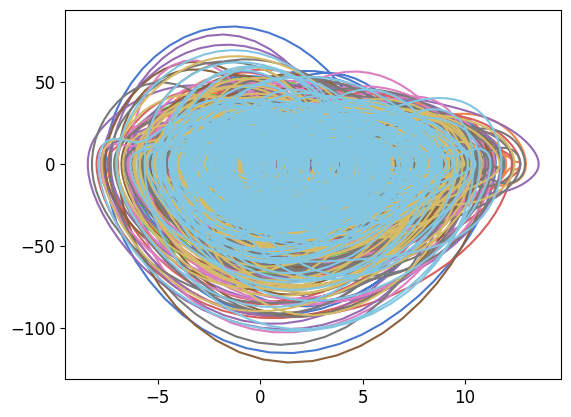

Training input shape: (15000, 10)
Training output shape: (15000, 10)


In [47]:
# Specify the model type
MY_MODEL = 'Lorenz_96' 
MY_DATA_TYPE = 'float32'

# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  

# Generate data based on the specified model type
LORENZ96_DIM = 10  #set up the dimension of the Lorenz 96 model

num_traj = 3
data_initial_conditions = DG.DataGenerator.generate_initial_conditions(LORENZ96_DIM, num_traj, seed=42) #np.random.normal(1, 2, LORENZ96_DIM

data_T =  50.0       # Length of the data (T)
data_dt = 0.01       # Resolution of the data (dt)
myDG = DG.DataGenerator(data_initial_conditions, T=data_T, dt=data_dt, derivative_mode="exact")
t_arr, x_train, dx_train, default_guessed_multiplicative_order = myDG.generate_dataset_by_model_name(MY_MODEL, method='DOP853')

print("Guessed highest order polynomial:", default_guessed_multiplicative_order)

#plot x_train and dx_train
import matplotlib.pyplot as plt
plt.plot(x_train, dx_train)
plt.show()

#Shuffle data
training_input, training_output = x_train, dx_train #data will be shuffled in the trainer


print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)

### **1.3 Hyperparameters**


In [48]:
# Set mini-batch size
MINI_BATCH_SIZE = 32
learning_rate = 0.01

### **1.4 Model Architecture Definitions**


**SREINet Parameters**

In [49]:
dim = training_input.shape[1] # the number of input state variables

# The grid size of each dimension
layer_depth = default_guessed_multiplicative_order + 4
layer_neuron_nums_per_act_fn = [dim] * layer_depth
print(layer_neuron_nums_per_act_fn) # these numbers exclude the constant term

[10, 10, 10, 10, 10, 10]


## **II. Model and Training Preparation**


### **2.1 Create the SREINet Model**


In [50]:
my_activation = [lambda x:x]
inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn,
                     activations=my_activation,
                     weight_initializer=tf.initializers.random_normal(stddev=0.01, seed=42),
                     data_type=MY_DATA_TYPE,
                     name='SREINet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)


### **2.2 Loss Function**

In [51]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)

from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**

In [52]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 Trainer**

In [53]:
from sreinet_trainer import *

trainer = SREINetTrainer(model, my_optimizer, loss_fn, data_type='float32')

## **III.Training the Model**

#### **Pruning Profile**

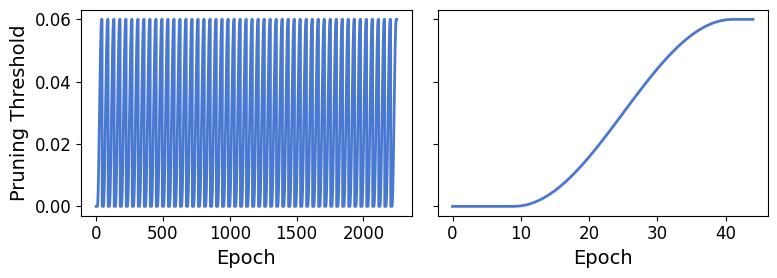

In [54]:
MAX_WEIGHT_PRUNING_THRESHOLD = 0.06
N_PERIODS = 50
PRUNING_EPOCHS_PER_PERIOD = 45
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_scheduler as ps

pruning_scheduler = ps.PruningScheduler(steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                    num_periods=N_PERIODS,
                    maximum_threshold=MAX_WEIGHT_PRUNING_THRESHOLD,
                    #ramp_type='sigmoid',
                    show_plot=True)

### Training

In [55]:
#Setup
EARLY_STOPPING_LOSS_THRESHOLD = 1e-10   # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.05

training_histories = []
weights_list = []
loss_list = []

In [56]:
for i in range(training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    output = training_output[:, i:i+1]
    
    history = trainer.fit(training_input, output,
     batch_size=MINI_BATCH_SIZE, 
     validation_split=0.20,
     epochs=round(NUM_EPOCHS), 
     pruning_scheduler=pruning_scheduler,
     early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,
     early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD,
     shuffle_per_epoch=False,
     patience_periods=15,
     verbose=1,
    )
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([trainer.get_best_weights()])
    loss_list.append(trainer.get_best_loss())

    #reset the model and trainer
    trainer.reset_trainer_and_model_weights(i)   

Training dimension 1...
Epoch   1 (Period 1):  Train Loss: 9.623e+01,  Validation Loss: 1.837e+01,  Epoch Time: 1.10s,  Current Pruning Threshold: 0
Epoch   2 (Period 1):  Train Loss: 9.663e+00,  Validation Loss: 7.812e+00,  Epoch Time: 0.41s,  Current Pruning Threshold: 0
Epoch   3 (Period 1):  Train Loss: 6.768e+00,  Validation Loss: 5.515e+00,  Epoch Time: 0.34s,  Current Pruning Threshold: 0
Epoch   4 (Period 1):  Train Loss: 3.648e+00,  Validation Loss: 3.704e+00,  Epoch Time: 0.34s,  Current Pruning Threshold: 0
Epoch   5 (Period 1):  Train Loss: 3.873e+00,  Validation Loss: 3.483e+00,  Epoch Time: 0.34s,  Current Pruning Threshold: 0
Epoch   6 (Period 1):  Train Loss: 3.511e+00,  Validation Loss: 4.812e+00,  Epoch Time: 0.34s,  Current Pruning Threshold: 0
Epoch   7 (Period 1):  Train Loss: 1.530e+05,  Validation Loss: 1.482e+04,  Epoch Time: 0.34s,  Current Pruning Threshold: 0
Epoch   8 (Period 1):  Train Loss: 2.447e+03,  Validation Loss: 9.496e+02,  Epoch Time: 0.34s,  Curre

## **IV. Coefficient Reconstructor**

#### `generate_set_labels`

The section below generates the layer labels that will be used to recontruct the symbolic of the right hand side (RHS) of governing equations. In addition, it also generates LHS labels.

In [57]:
def generate_layer_labels(N):
    return ['Constant'] + [f'x{i}' for i in range(1, N+1)]

def generate_LHS_labels(N):
    return [f"(x{i})'" for i in range(1, N+1)]

#### `coefficient_reconstruction`

In [58]:
from coefficient_reconstructor import *
cr = CoefficientReconstructor(generate_layer_labels, generate_LHS_labels)

## **V. Results**
### **Identified Model**

In [59]:
eq_str = []
for i in range(len(weights_list)):
    path_products = cr.reconstruct_coefficients(i,
                                               weights_list[i], 
                                            minimum_coefficient_threshold = 1e-2,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")
        eq_str.append(dimension)

(x1)' = 8.000000208 - 0.9999999476*x1 - 1.000000049*x10*x9 + 1.000000018*x10*x2
(x2)' = 7.9999995 - 0.9999998238*x2 + 0.9999999879*x1*x3 - 0.9999999673*x1*x10
(x3)' = 8.000000191 - 1.000000026*x1*x2 + 1.000000026*x2*x4 - 1.000000084*x3
(x4)' = 7.999998089 - 1.000000469*x2*x3 + 1.000000421*x3*x5 - 1.000000034*x4
(x5)' = 8.000001644 - 0.9999994029*x5 - 1.000000169*x3*x4 + 1.000000169*x4*x6
(x6)' = 7.999999187 - 1.000000005*x4*x5 - 0.9999999773*x6 + 1.000000005*x5*x7
(x7)' = 8.000000026 - 1.000000153*x5*x6 + 0.9999999818*x6*x8 - 0.999999993*x7
(x8)' = 7.999999961 - 0.9999999952*x8 - 0.9999999675*x6*x7 + 0.9999999675*x7*x9
(x9)' = 8.00000055 - 0.9999995271*x7*x8 + 1.000000069*x10*x8 - 0.9999997233*x9
(x10)' = 7.999999984 - 0.999999998*x10 + 0.9999999904*x1*x9 - 0.9999999124*x8*x9


In [60]:
loss_list

[3.0745012e-12,
 2.9714644e-12,
 1.9159932e-12,
 1.2099135e-11,
 4.4889228e-11,
 2.9414398e-12,
 8.027341e-12,
 2.0181873e-12,
 1.40395915e-11,
 3.5345429e-12]

### **Validation**

In [61]:
import model_reconstructor as mr

recovered_model = mr.RecoveredModel()
recovered_model.parse_ode_equations(eq_str);


### Comparing vector field

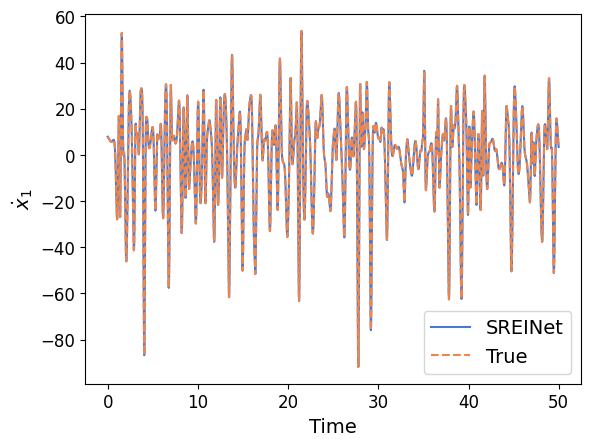

In [62]:
pred_x_dot = recovered_model.predict_derivatives(x_train)

val_t_span = [0,data_T]
val_t_eval = np.arange(0,data_T,data_dt)

import matplotlib.pyplot as plt

plt.plot(val_t_eval, pred_x_dot[:val_t_eval.shape[0], 0],label='SREINet')
plt.plot(val_t_eval, dx_train[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time')
plt.ylabel(r'$\dot{x}_1$')
plt.legend()
plt.show()

### Comparing response

In [63]:
val_t_span = [0,data_T]
val_t_eval = np.arange(0,data_T,data_dt)

validation_result = recovered_model.simulate(data_initial_conditions[0], t_span=val_t_span,t_eval=val_t_eval, method='DOP853')

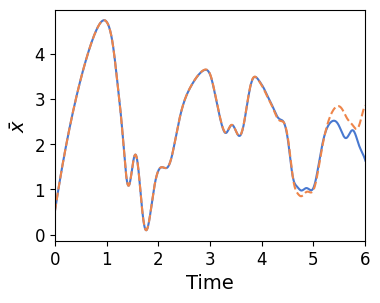

In [64]:
import matplotlib.pyplot as plt

#plot average of validation_result['y']
val_avg = np.mean(validation_result['y'], axis=0)
x_train_avg = np.mean(x_train, axis=1)

figure_size = (4,3)
plt.figure(figsize=figure_size)
plt.plot(validation_result['t'], val_avg,label='SREINet')
plt.plot(val_t_eval, x_train_avg[:val_t_eval.shape[0]], '--', label='True')
plt.xlabel('Time')
plt.ylabel(r'$\bar{x}$')
plt.xlim(0, 6)
#plt.legend()
plt.show()
#plt.savefig('SREINet_Lorenz96_5-layers_x3.png',dpi=600)

In [65]:
score =recovered_model.score(x_train[:val_t_eval.shape[0]], dx_train[:val_t_eval.shape[0]])
print(f"Score: {score}")

complexity = recovered_model.calculate_complexity()
print(f"Complexity: {complexity}")

complexity_per_dimension = complexity//dim
print(f"Complexity per dimension: {complexity_per_dimension}")

Score: 0.9999999999999416
Complexity: 40
Complexity per dimension: 4


## **VI. Output**

In [66]:
# Output validation results to numpy file
np.savez_compressed('output/validation_results_6layers.npz',
                    t=validation_result['t'],
                    val_avg=val_avg,
                    val_t_eval=val_t_eval,
                    x_train_avg=x_train_avg)
print("Validation results saved to 'validation_results_6layers.npz'")



Validation results saved to 'validation_results_6layers.npz'
